In [1]:
import pandas as pd
import numpy as np
from color_image_notebook import ColorImageMaker

# Optional: configure matplotlib for notebooks
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from glob import glob
from astropy.io import fits
import pandas as pd
from astropy.time import Time
not_files = glob('/Users/kryanhinds/sedm_phot/data/NOT_imaging/*/*.fits')+glob('/Users/kryanhinds/sedm_phot/data/NOT_20260423-24/*.fits')
tjo_files = glob('/Users/kryanhinds/sedm_phot/data/TJO/*.fits')
lt_files  = glob('/Users/kryanhinds/sedm_phot/data/ZTF26aakjzdt_LT/*/*.fits')

all_files = not_files + tjo_files + lt_files

#extract filter, MJD, and instrument from each filename and store in a DataFrame + filename

not_kw = {'filt':'FAFLTNM','obs_date':'DATE-OBS','inst':'NOT/ALFOSC','exp_time':'EXPTIME'}
tjo_kw = {'filt':'FILTER','obs_date':['DATE-OBS','TIME-OBS'],'inst':'TJO/MEIA2','exp_time':'EXPTIME'}
lt_kw  = {'filt':'FILTER1','obs_date':'DATE-OBS','inst':'LT/IOO','exp_time':'EXPTIME'}

data = []
for f in all_files:
    with fits.open(f) as hdul:
        hdr = hdul[0].header
        if 'NOT' in f:
            filt = hdr[not_kw['filt']][0]
            obs_date = hdr[not_kw['obs_date']]
            exp_time = hdr[not_kw['exp_time']]
            inst = not_kw['inst']
        elif 'TJO' in f:
            filt = hdr[tjo_kw['filt']][-1]
            obs_date = Time(hdr[tjo_kw['obs_date'][0]] + 'T' + hdr[tjo_kw['obs_date'][1]]).iso
            exp_time = hdr[tjo_kw['exp_time']]
            inst = tjo_kw['inst']
        elif 'LT' in f:
            filt = hdr[lt_kw['filt']][-1].lower()
            obs_date = hdr[lt_kw['obs_date']]
            exp_time = hdr[lt_kw['exp_time']]
            inst = lt_kw['inst']
        else:
            continue
        
        obs_mjd = Time(obs_date).mjd + (exp_time/2) / 86400.0
        data.append({'filename': f, 'instrument': inst, 'filter': filt, 'obs_date': obs_date, 'obs_mjd': obs_mjd, 'exp_time': exp_time})

df = pd.DataFrame(data)

In [ ]:
from seeing_measure import measure_seeing_batch, add_seeing_to_dataframe, seeing_summary

# Option 1: Add directly to your DataFrame
df = add_seeing_to_dataframe(df, threshold=3.0, verbose=True)

# Option 2: Just get the seeing values
df['seeing'] = measure_seeing_batch(df['filename'], df['instrument'])

# Get statistics
stats = seeing_summary(df['seeing'], by_filter=df['filter'], by_instrument=df['instrument'])
print(f"Median seeing: {stats['median']:.2f}\"")
print(f"\nBy filter:")
for filt, info in stats['by_filter'].items():
    print(f"  {filt}: {info['median']:.2f}\" (n={info['count']})")

print(f"\nBy instrument:")
for inst, info in stats['by_instrument'].items():
    print(f"  {inst}: {info['median']:.2f}\" (n={info['count']})")

# Then select good images for color composite
df_good = df[df['seeing'] < 1.5]  # Select images better than 1.5"

#

[1/97] GRB260310A_astro_g.fits...   FWHM: 2.64 pix → 0.50 arcsec
✓ 0.50"
[2/97] GRB260310A_astro_r.fits... 

/Users/kryanhinds/sedm_phot/seeing_measure.py:213: RuntimeWarning: invalid value encountered in sqrt
  sigma_mean = np.sqrt(sigma_x * sigma_y)


  FWHM: 2.31 pix → 0.44 arcsec
✓ 0.44"
[3/97] GRB260310A_astro_z.fits...   FWHM: 1.85 pix → 0.35 arcsec
✓ 0.35"
[4/97] GRB260310A_astro_i.fits...   FWHM: 5.51 pix → 1.04 arcsec
✓ 1.04"
[5/97] GRB260310A_astro_g.fits...   FWHM: 0.79 pix → 0.15 arcsec
✓ 0.15"
[6/97] GRB260310A_astro_r.fits...   FWHM: 0.77 pix → 0.15 arcsec
✓ 0.15"
[7/97] GRB260310A_astro_z.fits...   FWHM: 4.33 pix → 0.82 arcsec
✓ 0.82"
[8/97] GRB260310A_astro_i.fits...   FWHM: 4.66 pix → 0.88 arcsec
✓ 0.88"
[9/97] GRB260310A_astro_g.fits...   FWHM: 4.57 pix → 0.86 arcsec
✓ 0.86"
[10/97] GRB260310A_astro_r.fits...   FWHM: 4.60 pix → 0.87 arcsec
✓ 0.87"
[11/97] GRB260310A_astro_z.fits...   FWHM: 9.75 pix → 1.84 arcsec
✓ 1.84"
[12/97] GRB260310A_astro_i.fits...   FWHM: 2.90 pix → 0.55 arcsec
✓ 0.55"
[13/97] GRB260310A_astro_g.fits...   FWHM: 4.77 pix → 0.90 arcsec
✓ 0.90"
[14/97] GRB260310A_astro_r.fits...   FWHM: 2.72 pix → 0.51 arcsec
✓ 0.51"
[15/97] GRB260310A_astro_u.fits...   FWHM: 2.17 pix → 0.41 arcsec
✓ 0.41"
[16/97

/Users/kryanhinds/sedm_phot/seeing_measure.py:204: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


  FWHM: 2.34 pix → 0.44 arcsec
✓ 0.44"
[18/97] GRB260310A_astro_i.fits...   FWHM: 2.12 pix → 0.40 arcsec
✓ 0.40"
[19/97] GRB260310A_i_Apr23.fits...   FWHM: 4.92 pix → 0.93 arcsec
✓ 0.93"
[20/97] GRB260310A_r_Apr23.fits...   FWHM: 3.68 pix → 0.70 arcsec
✓ 0.70"
[21/97] GRB260310A_g_Apr23.fits...   FWHM: 4.95 pix → 0.94 arcsec
✓ 0.94"
[22/97] stacked_rband_20260417.fits...   FWHM: 4.05 pix → 1.23 arcsec
✓ 1.23"
[23/97] stacked_iband_20260323.fits...   FWHM: 8.60 pix → 2.62 arcsec
✓ 2.62"
[24/97] stacked_gband_20260408.fits...   FWHM: 4.48 pix → 1.36 arcsec
✓ 1.36"
[25/97] stacked_rband_20260323.fits...   FWHM: 8.32 pix → 2.53 arcsec
✓ 2.53"
[26/97] stacked_iband_20260417.fits...   FWHM: 3.87 pix → 1.18 arcsec
✓ 1.18"
[27/97] stacked_gband_20260320.fits...   FWHM: 8.86 pix → 2.69 arcsec
✓ 2.69"
[28/97] stacked_gband_20260419.fits...   FWHM: 5.15 pix → 1.57 arcsec
✓ 1.57"
[29/97] stacked_iband_20260408.fits...   FWHM: 3.98 pix → 1.21 arcsec
✓ 1.21"
[30/97] stacked_gband_20260323.fits...   

/Users/kryanhinds/sedm_phot/seeing_measure.py:213: RuntimeWarning: invalid value encountered in sqrt
  sigma_mean = np.sqrt(sigma_x * sigma_y)


  FWHM: 1.85 pix → 0.35 arcsec
✓ 0.35"
[4/97] GRB260310A_astro_i.fits...   FWHM: 5.51 pix → 1.04 arcsec
✓ 1.04"
[5/97] GRB260310A_astro_g.fits...   FWHM: 0.79 pix → 0.15 arcsec
✓ 0.15"
[6/97] GRB260310A_astro_r.fits...   FWHM: 0.77 pix → 0.15 arcsec
✓ 0.15"
[7/97] GRB260310A_astro_z.fits...   FWHM: 4.33 pix → 0.82 arcsec
✓ 0.82"
[8/97] GRB260310A_astro_i.fits...   FWHM: 4.66 pix → 0.88 arcsec
✓ 0.88"
[9/97] GRB260310A_astro_g.fits...   FWHM: 4.57 pix → 0.86 arcsec
✓ 0.86"
[10/97] GRB260310A_astro_r.fits...   FWHM: 4.60 pix → 0.87 arcsec
✓ 0.87"
[11/97] GRB260310A_astro_z.fits...   FWHM: 9.75 pix → 1.84 arcsec
✓ 1.84"
[12/97] GRB260310A_astro_i.fits...   FWHM: 2.90 pix → 0.55 arcsec
✓ 0.55"
[13/97] GRB260310A_astro_g.fits...   FWHM: 4.77 pix → 0.90 arcsec
✓ 0.90"
[14/97] GRB260310A_astro_r.fits...   FWHM: 2.72 pix → 0.51 arcsec
✓ 0.51"
[15/97] GRB260310A_astro_u.fits...   FWHM: 2.17 pix → 0.41 arcsec
✓ 0.41"
[16/97] GRB260310A_astro_z.fits...   FWHM: 1.24 pix → 0.23 arcsec
✓ 0.23"
[17/9

/Users/kryanhinds/sedm_phot/seeing_measure.py:204: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


  FWHM: 2.34 pix → 0.44 arcsec
✓ 0.44"
[18/97] GRB260310A_astro_i.fits...   FWHM: 2.12 pix → 0.40 arcsec
✓ 0.40"
[19/97] GRB260310A_i_Apr23.fits...   FWHM: 4.92 pix → 0.93 arcsec
✓ 0.93"
[20/97] GRB260310A_r_Apr23.fits...   FWHM: 3.68 pix → 0.70 arcsec
✓ 0.70"
[21/97] GRB260310A_g_Apr23.fits...   FWHM: 4.95 pix → 0.94 arcsec
✓ 0.94"
[22/97] stacked_rband_20260417.fits...   FWHM: 4.05 pix → 1.23 arcsec
✓ 1.23"
[23/97] stacked_iband_20260323.fits...   FWHM: 8.60 pix → 2.62 arcsec
✓ 2.62"
[24/97] stacked_gband_20260408.fits...   FWHM: 4.48 pix → 1.36 arcsec
✓ 1.36"
[25/97] stacked_rband_20260323.fits...   FWHM: 8.32 pix → 2.53 arcsec
✓ 2.53"
[26/97] stacked_iband_20260417.fits...   FWHM: 3.87 pix → 1.18 arcsec
✓ 1.18"
[27/97] stacked_gband_20260320.fits...   FWHM: 8.86 pix → 2.69 arcsec
✓ 2.69"
[28/97] stacked_gband_20260419.fits...   FWHM: 5.15 pix → 1.57 arcsec
✓ 1.57"
[29/97] stacked_iband_20260408.fits...   FWHM: 3.98 pix → 1.21 arcsec
✓ 1.21"
[30/97] stacked_gband_20260323.fits...   

ValueError: DataFrame missing required column: 'mjd'

No temporal groups found
Empty DataFrame
Columns: []
Index: []


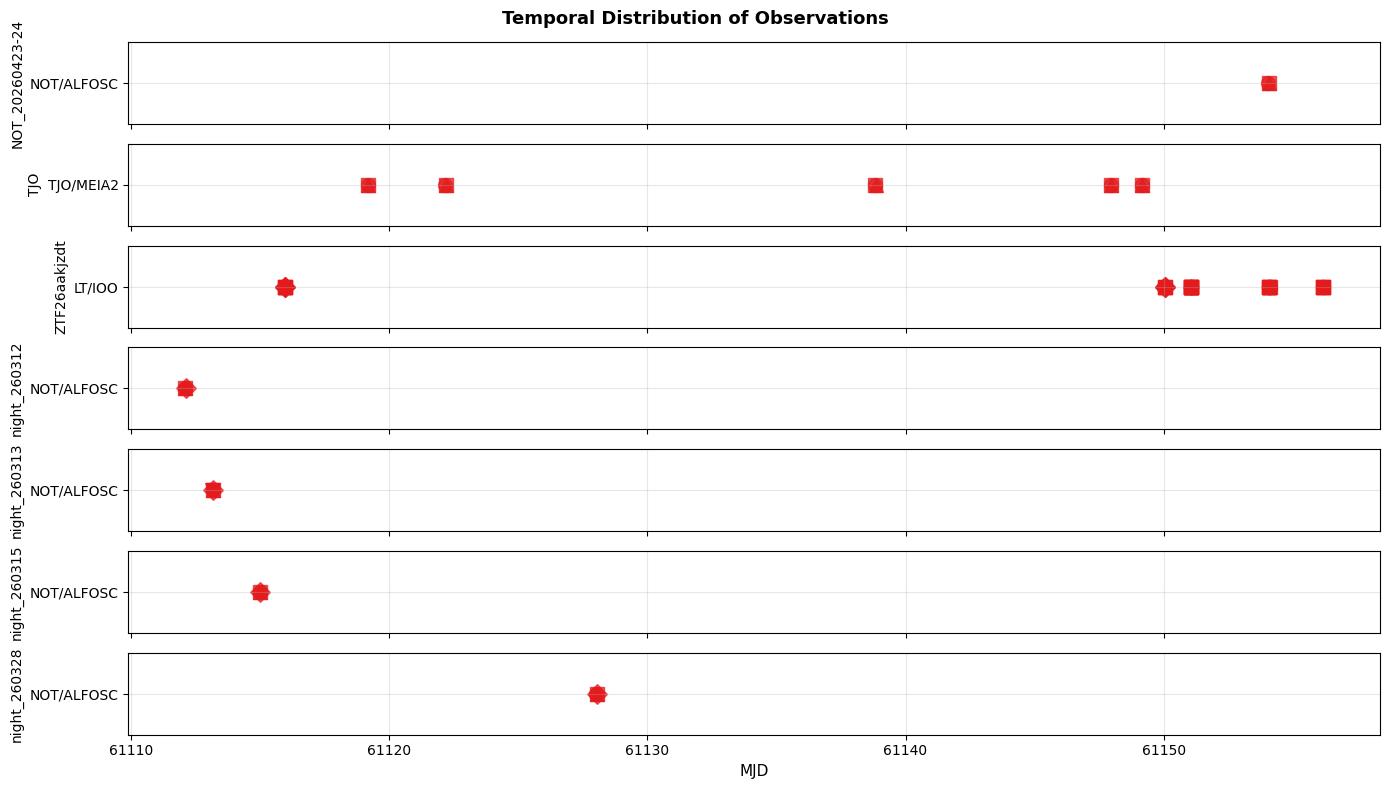

ValueError: Object 'ZTF26aakjzdt' not in groups. Available: []

In [4]:
from temporal_grouping import (
    find_temporal_groups, extract_object_name, 
    summarize_groups, print_groups, select_group,
    plot_temporal_distribution, filter_coverage
)

# Add object names to your DataFrame
df['object'] = df['filename'].apply(extract_object_name)

# Find temporal groups (within 1 day, NOT and LT only)
groups = find_temporal_groups(
    df,
    time_window=1.0,  # 1 day
    instruments=['NOT/ALFOSC', 'LT/IOO'],
    require_filters=['g', 'r', 'i']  # Only these filters
)

# See what you've got
print_groups(groups, verbose=True)

# Get a summary table
summary = summarize_groups(groups)
print(summary)
#   object            group_id  num_images filters     instruments      mjd_span_days
# ZTF26aakjzdt           0          6      g,i,r  NOT/ALFOSC,LT/IOO        0.0043
# ZTF26aakjzdt           1          4      g,r    NOT/ALFOSC,LT/IOO        0.0057

# Plot temporal distribution
fig = plot_temporal_distribution(df)
plt.show()

# Select a specific group for color composite
group_1 = select_group(groups, 'ZTF26aakjzdt', group_id=0)

# Check what filters you have
coverage = filter_coverage(group_1)
print(coverage)
# {'NOT/ALFOSC': ['g', 'i', 'r'], 'LT/IOO': ['g', 'r']}

# Add seeing measurements
from seeing_measure import measure_seeing_batch
group_1 = group_1.copy()
group_1['seeing'] = measure_seeing_batch(group_1['filename'], group_1['instrument'])

# Keep only good seeing
group_1_good = group_1[group_1['seeing'] < 1.5]

# Make color image
from color_image_notebook import ColorImageMaker
maker = ColorImageMaker()
rgb, info = maker.create_from_dataframe(group_1_good, output_path='color_ZTF26aakjzdt.png')
maker.plot()

In [5]:
# First, check what you have
print("DataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df[['filename', 'instrument', 'filter', 'obs_mjd']].head(10))

# Check extracted object names
df['object'] = df['filename'].apply(extract_object_name)
print("\nUnique objects:")
print(df['object'].unique())

# Check what instruments you have
print("\nUnique instruments:")
print(df['instrument'].unique())

# Check what filters you have
print("\nUnique filters:")
print(df['filter'].unique())

# Check how many of each instrument
print("\nInstrument counts:")
print(df['instrument'].value_counts())

# Most importantly: are there NOT and LT images close in time?
print("\nMJD ranges by instrument:")
for inst in df['instrument'].unique():
    inst_df = df[df['instrument'] == inst]
    print(f"  {inst}: {inst_df['obs_mjd'].min():.3f} - {inst_df['obs_mjd'].max():.3f}")

# Check for same object observations
print("\nObservations per object and instrument:")
for obj in df['object'].unique():
    obj_df = df[df['object'] == obj]
    print(f"\n  {obj}:")
    for inst in obj_df['instrument'].unique():
        count = len(obj_df[obj_df['instrument'] == inst])
        mjds = obj_df[obj_df['instrument'] == inst]['obs_mjd'].values
        print(f"    {inst}: {count} images, MJD: {mjds.min():.3f} - {mjds.max():.3f}")

DataFrame shape: (97, 8)

First few rows:
                                            filename  instrument filter  \
0  /Users/kryanhinds/sedm_phot/data/NOT_imaging/n...  NOT/ALFOSC      g   
1  /Users/kryanhinds/sedm_phot/data/NOT_imaging/n...  NOT/ALFOSC      r   
2  /Users/kryanhinds/sedm_phot/data/NOT_imaging/n...  NOT/ALFOSC      z   
3  /Users/kryanhinds/sedm_phot/data/NOT_imaging/n...  NOT/ALFOSC      i   
4  /Users/kryanhinds/sedm_phot/data/NOT_imaging/n...  NOT/ALFOSC      g   
5  /Users/kryanhinds/sedm_phot/data/NOT_imaging/n...  NOT/ALFOSC      r   
6  /Users/kryanhinds/sedm_phot/data/NOT_imaging/n...  NOT/ALFOSC      z   
7  /Users/kryanhinds/sedm_phot/data/NOT_imaging/n...  NOT/ALFOSC      i   
8  /Users/kryanhinds/sedm_phot/data/NOT_imaging/n...  NOT/ALFOSC      g   
9  /Users/kryanhinds/sedm_phot/data/NOT_imaging/n...  NOT/ALFOSC      r   

        obs_mjd  
0  61128.028560  
1  61128.041916  
2  61128.058145  
3  61128.049984  
4  61114.990754  
5  61114.995056  
6  611